First 5 records:
     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

EDA Summary:
              Age  Years of Experience         Salary
count  373.000000           373.000000     373.000000
mean    37.431635            10.030831  100577.345845
std      7.069073             6.557007   48240.013482
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.000000             9.000000   95000.000000
75%     44.000000            15.000000  140000.000000
m

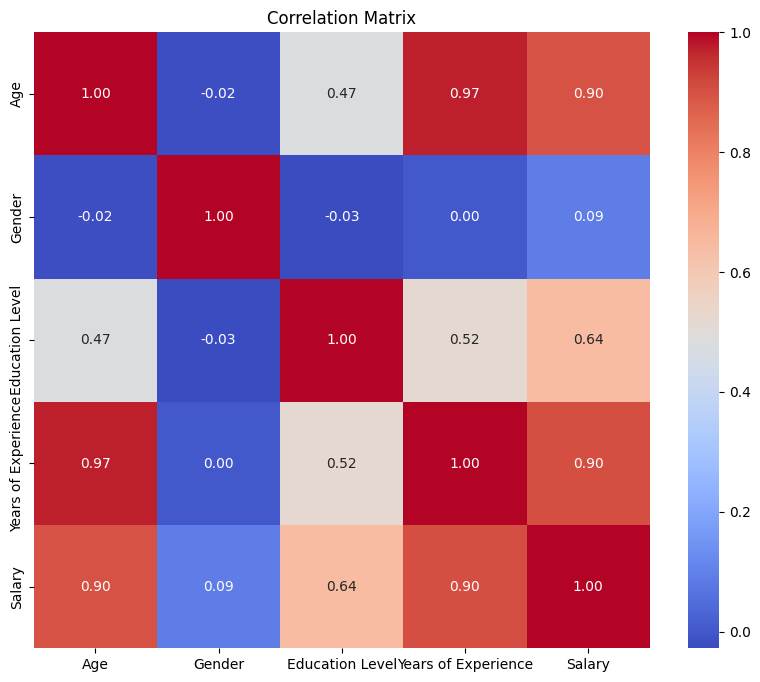


Plotting hist plots for numeric columns...


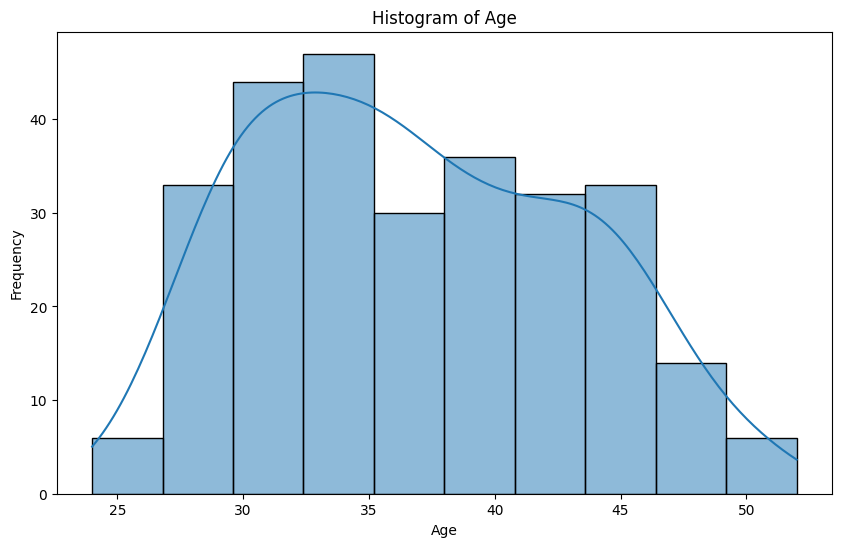

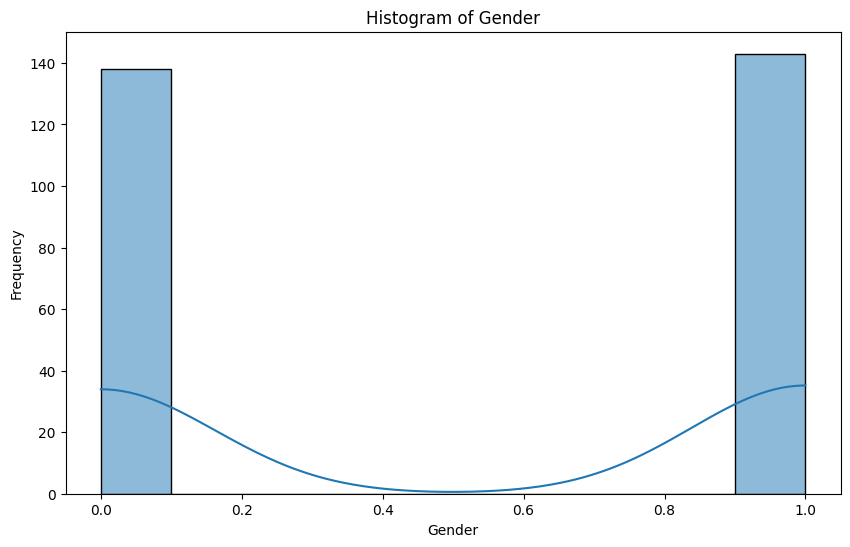

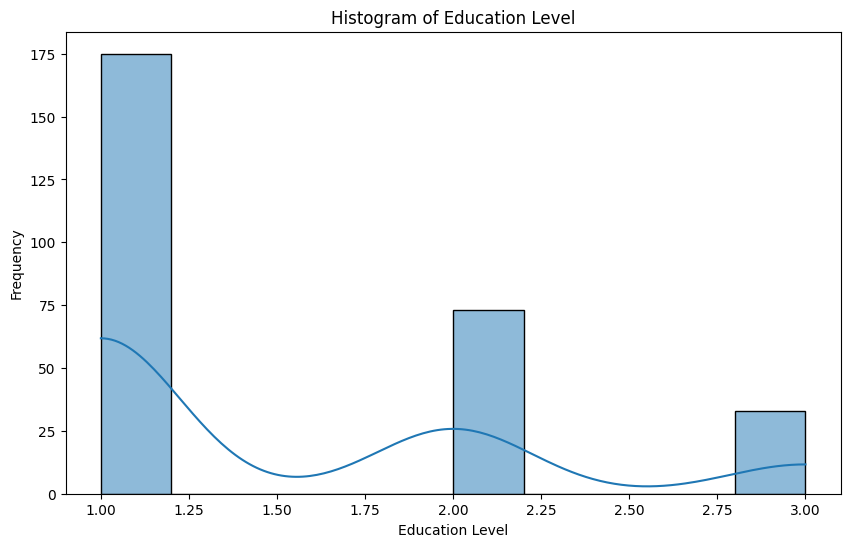

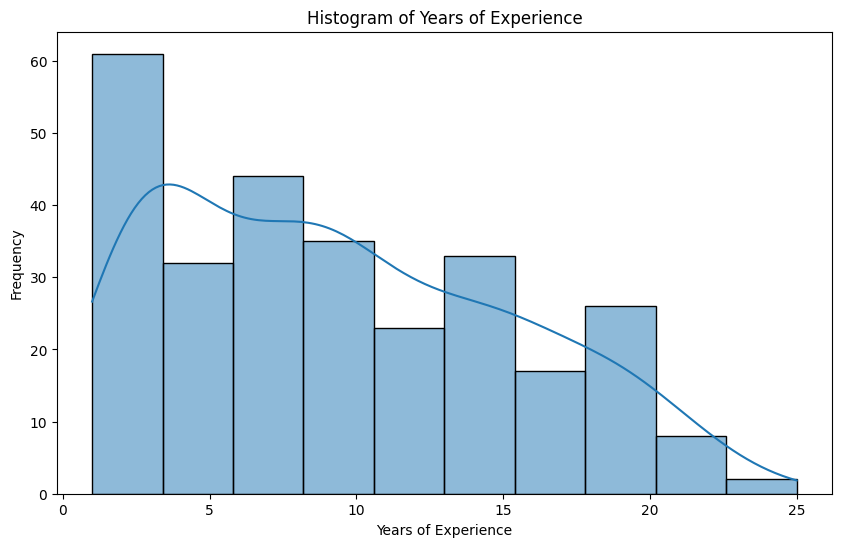

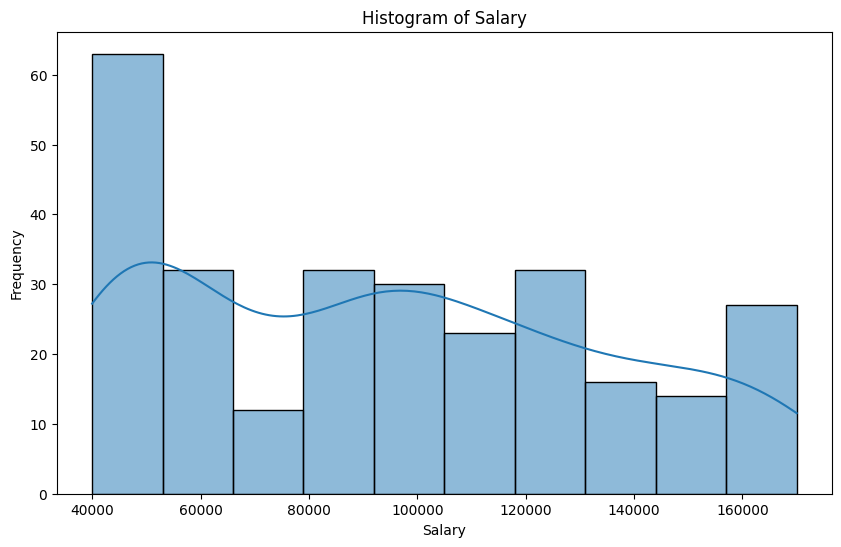


Converting 'Job Title' column to numeric with One-Hot Encoding...

Data types after conversion:
 Age                              float64
Gender                             int64
Education Level                    int64
Years of Experience              float64
Salary                           float64
                                  ...   
Job Title_Technical Writer          bool
Job Title_Training Specialist       bool
Job Title_UX Designer               bool
Job Title_UX Researcher             bool
Job Title_Web Developer             bool
Length: 156, dtype: object

Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 281 entries, 0 to 371
Columns: 156 entries, Age to Job Title_Web Developer
dtypes: bool(151), float64(3), int64(2)
memory usage: 54.6 KB
None

First 5 records of cleaned DataFrame:
     Age  Gender  Education Level  Years of Experience    Salary  \
0  32.0       1                1                  5.0   90000.0   
1  28.0       0                2

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf

# Set the path to the file you'd like to load
file_path = 'Salary Data.csv'

# Load the CSV with the correct encoding
df = pd.read_csv(file_path, encoding='utf-8', delimiter=',')

print("First 5 records:\n", df.head())

print("\nEDA Summary:")
print(df.describe())

print("\nHow categorical variables are distributed:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

print("\nMissing values per column:\n", df.isnull().sum())

print("\nData types:\n", df.dtypes)

print("\nDataFrame shape after deletion:", df.shape)

print("\nColumn names:", df.columns.tolist())

print("\nDeleting rows with any missing values...")
df = df.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df.shape)

print("\nDeleting duplicate rows...")
df = df.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df.shape)

print("\nCleaning outliers in 'Salary' column deleting upper and lower 10% outliers...")
lower_salary_threshold = df['Salary'].quantile(0.10)
upper_salary_threshold = df['Salary'].quantile(0.90)
df = df[(df['Salary'] >= lower_salary_threshold) & (df['Salary'] <= upper_salary_threshold)]
print("\nDataFrame shape after cleaning outliers in 'Salary':", df.shape)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nConverting 'Education Level' column to numeric using mapping...")
education_mapping = {
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3,
}
df['Education Level'] = df['Education Level'].map(education_mapping)

print("\nConverting 'Gender' column to numeric with mapping...")
gender_mapping = {
    "Male": 1,
    "Female": 0,
}
df['Gender'] = df['Gender'].map(gender_mapping)

print("\nMatrix of correlations:\n")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()
    
print("\nPlotting hist plots for numeric columns...")
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

print("\nConverting 'Job Title' column to numeric with One-Hot Encoding...")
df = pd.get_dummies(df, columns=['Job Title'], drop_first=True)
    
print("\nData types after conversion:\n", df.dtypes)

print("\nFinal cleaned DataFrame info:")
print(df.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df.head())

print("\nData cleaning completed.")
print("\nNOTA: El escalado se realizará después de la separación train/test en cada modelo.")



Splitting data: 60% train, 20% validation, 20% test...
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 1 (1 característica)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1791 - val_loss: 0.0615
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0576 - val_loss: 0.0454
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0424 - val_loss: 0.0322
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0304 - val_loss: 0.0313
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0229 - val_loss: 0.0187
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0188 - val_loss: 0.0212
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0193 - val_loss: 0.0180
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0174 - val_loss: 0.0186
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0191 - val_loss: 0.0171
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0170 - val_loss: 0.0204
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0167 - val_loss: 0.0174
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0163 - val_loss: 0.0195
E

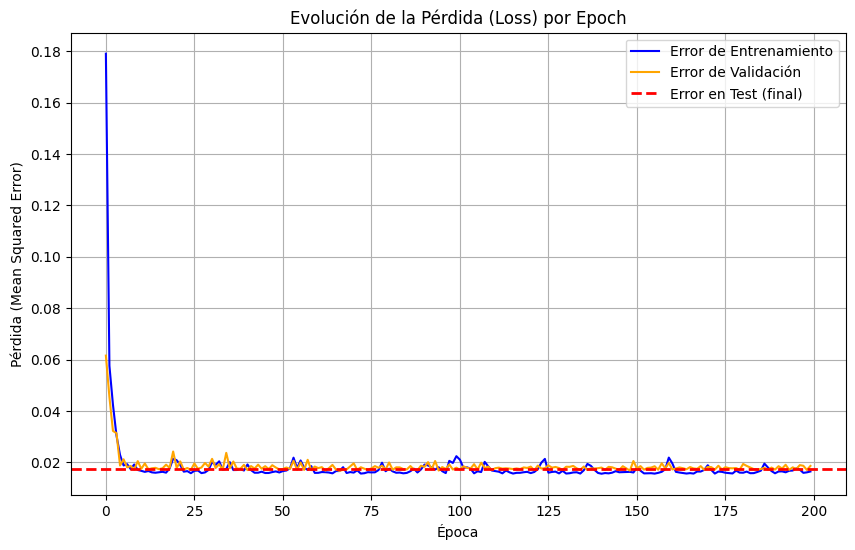

In [168]:
X = df[['Years of Experience']]
y = df['Salary']

print("\nSplitting data: 60% train, 20% validation, 20% test...")
# Primera división: separar test (20%)
X_temp, X_test_1, y_temp, y_test_1 = train_test_split(X, y, test_size=0.20, random_state=42)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_1 = MinMaxScaler()
scaler_y_1 = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_1_scaled = scaler_X_1.fit_transform(X_train_1)
y_train_1_scaled = scaler_y_1.fit_transform(y_train_1.values.reshape(-1, 1)).flatten()

# Solo transformar validation y test (sin fit)
X_val_1_scaled = scaler_X_1.transform(X_val_1)
y_val_1_scaled = scaler_y_1.transform(y_val_1.values.reshape(-1, 1)).flatten()

X_test_1_scaled = scaler_X_1.transform(X_test_1)
y_test_1_scaled = scaler_y_1.transform(y_test_1.values.reshape(-1, 1)).flatten()

# Modelo Simple
model_1 = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_1_scaled.shape[1]], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 1 (1 característica)...')
history_1 = model_1.fit(X_train_1_scaled, y_train_1_scaled, epochs=200, validation_data=(X_val_1_scaled, y_val_1_scaled))

# Evaluación final con el conjunto de TEST
loss_1 = model_1.evaluate(X_test_1_scaled, y_test_1_scaled, verbose=0)
print(f'Pérdida Modelo 1 en Test: {loss_1}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_1.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_1, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()



Splitting data: 60% train, 20% validation, 20% test...
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 2 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2000 - val_loss: 0.0464
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0518 - val_loss: 0.0476
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0373 - val_loss: 0.0305
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0273 - val_loss: 0.0217
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 - val_loss: 0.0152
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0162 - val_loss: 0.0140
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0138 - val_loss: 0.0131
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0135 - val_loss: 0.0120
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0132 - val_loss: 0.0154
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0131 - val_loss: 0.0121
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0141 - val_loss: 0.0139
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0127 - val_loss: 0.0119
E

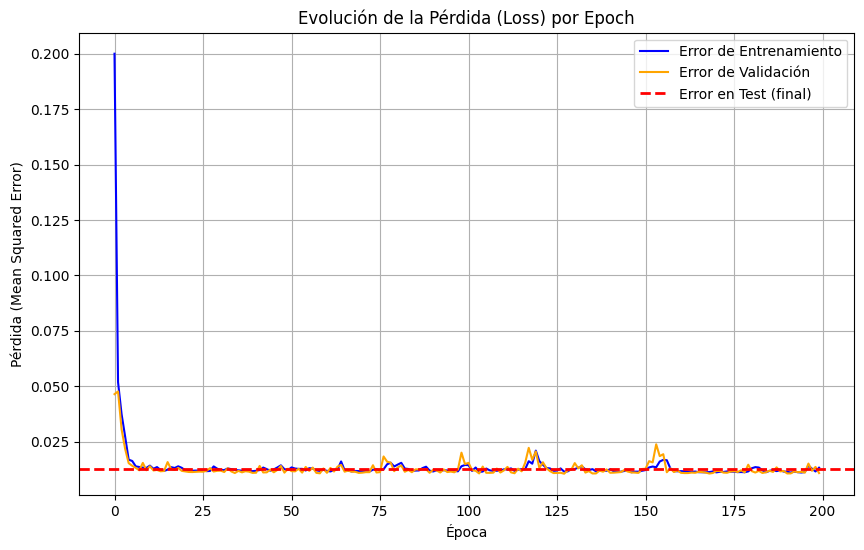

In [169]:
X = df[['Years of Experience', 'Education Level']]
y = df['Salary']

print("\nSplitting data: 60% train, 20% validation, 20% test...")
# Primera división: separar test (20%)
X_temp, X_test_M, y_temp, y_test_M = train_test_split(X, y, test_size=0.20, random_state=42)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M, X_val_M, y_train_M, y_val_M = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M = MinMaxScaler()
scaler_y_M = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_scaled = scaler_X_M.fit_transform(X_train_M)
y_train_M_scaled = scaler_y_M.fit_transform(y_train_M.values.reshape(-1, 1)).flatten()

# Solo transformar validation y test (sin fit)
X_val_M_scaled = scaler_X_M.transform(X_val_M)
y_val_M_scaled = scaler_y_M.transform(y_val_M.values.reshape(-1, 1)).flatten()

X_test_M_scaled = scaler_X_M.transform(X_test_M)
y_test_M_scaled = scaler_y_M.transform(y_test_M.values.reshape(-1, 1)).flatten()

# Modelo Multivariable
model_M = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_scaled.shape[1]], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 2 (Múltiples características)...')
history_M = model_M.fit(X_train_M_scaled, y_train_M_scaled, epochs=200, validation_data=(X_val_M_scaled, y_val_M_scaled))

# Evaluación final con el conjunto de TEST
loss_M = model_M.evaluate(X_test_M_scaled, y_test_M_scaled, verbose=0)
print(f'Pérdida Modelo 2 en Test: {loss_M}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()



Splitting data: 60% train, 20% validation, 20% test...
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 3 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1031 - val_loss: 0.0421
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0330 - val_loss: 0.0280
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0169 - val_loss: 0.0177
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080 - val_loss: 0.0139
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0127
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - val_loss: 0.0138
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - val_loss: 0.0131
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0032 - val_loss: 0.0139
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0029 - val_loss: 0.0129
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - val_loss: 0.0141
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - val_loss: 0.0140
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - val_loss: 0.0136
E

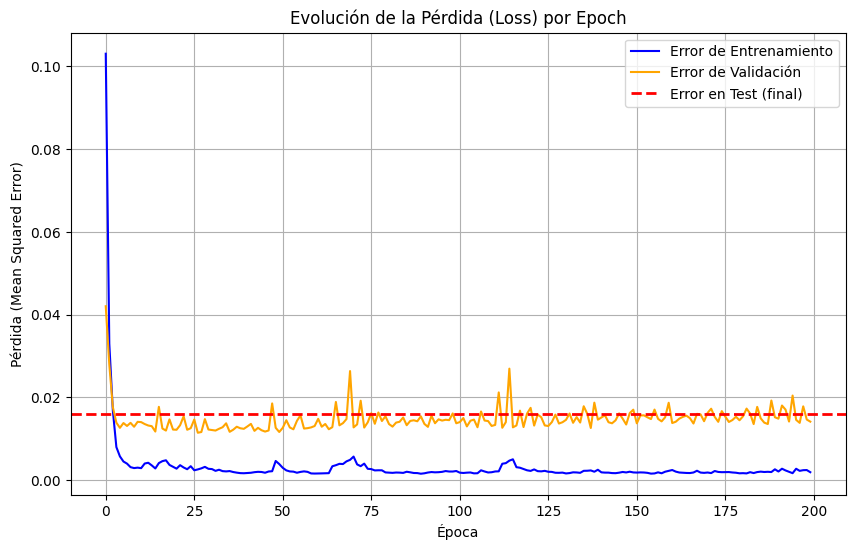

In [170]:
X = df.drop(columns=['Salary', 'Gender', 'Age'])
y = df['Salary']

print("\nSplitting data: 60% train, 20% validation, 20% test...")
# Primera división: separar test (20%)
X_temp, X_test_M_all, y_temp, y_test_M_all = train_test_split(X, y, test_size=0.20, random_state=42)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M_all, X_val_M_all, y_train_M_all, y_val_M_all = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M_all = MinMaxScaler()
scaler_y_M_all = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_all_scaled = scaler_X_M_all.fit_transform(X_train_M_all)
y_train_M_all_scaled = scaler_y_M_all.fit_transform(y_train_M_all.values.reshape(-1, 1)).flatten()

# Solo transformar validation y test (sin fit)
X_val_M_all_scaled = scaler_X_M_all.transform(X_val_M_all)
y_val_M_all_scaled = scaler_y_M_all.transform(y_val_M_all.values.reshape(-1, 1)).flatten()

X_test_M_all_scaled = scaler_X_M_all.transform(X_test_M_all)
y_test_M_all_scaled = scaler_y_M_all.transform(y_test_M_all.values.reshape(-1, 1)).flatten()

# Modelo Multivariable
model_M_all = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_all_scaled.shape[1]], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M_all.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 3 (Múltiples características)...')
history_M_all = model_M_all.fit(X_train_M_all_scaled, y_train_M_all_scaled, epochs=200, validation_data=(X_val_M_all_scaled, y_val_M_all_scaled))

# Evaluación final con el conjunto de TEST
loss_M_all = model_M_all.evaluate(X_test_M_all_scaled, y_test_M_all_scaled, verbose=0)
print(f'Pérdida Modelo 3 en Test: {loss_M_all}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M_all.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_all.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M_all, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()



Splitting data: 60% train, 20% validation, 20% test...
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 4 (1 característica)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3416 - val_loss: 0.1906
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2054 - val_loss: 0.1843
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1763 - val_loss: 0.1618
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1424 - val_loss: 0.1378
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1078 - val_loss: 0.1021
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1007 - val_loss: 0.1092
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0945 - val_loss: 0.0979
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0934 - val_loss: 0.0955
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0918 - val_loss: 0.0982
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0941 - val_loss: 0.1012
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1002 - val_loss: 0.1005
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0984 - val_loss: 0.1002
E

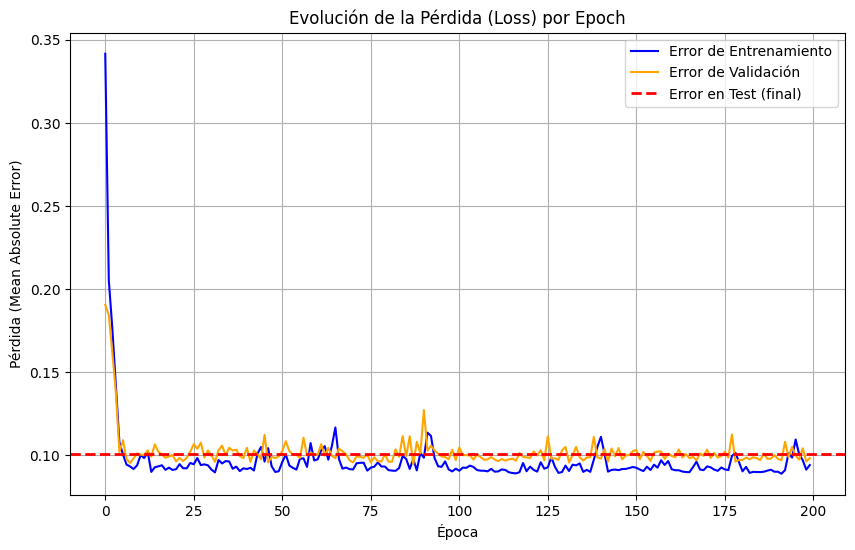

In [171]:
X = df[['Years of Experience']]
y = df['Salary']

print("\nSplitting data: 60% train, 20% validation, 20% test...")
# Primera división: separar test (20%)
X_temp, X_test_1_a, y_temp, y_test_1_a = train_test_split(X, y, test_size=0.20, random_state=42)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_1_a, X_val_1_a, y_train_1_a, y_val_1_a = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_1_a = MinMaxScaler()
scaler_y_1_a = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_1_a_scaled = scaler_X_1_a.fit_transform(X_train_1_a)
y_train_1_a_scaled = scaler_y_1_a.fit_transform(y_train_1_a.values.reshape(-1, 1)).flatten()

# Solo transformar validation y test (sin fit)
X_val_1_a_scaled = scaler_X_1_a.transform(X_val_1_a)
y_val_1_a_scaled = scaler_y_1_a.transform(y_val_1_a.values.reshape(-1, 1)).flatten()

X_test_1_a_scaled = scaler_X_1_a.transform(X_test_1_a)
y_test_1_a_scaled = scaler_y_1_a.transform(y_test_1_a.values.reshape(-1, 1)).flatten()

# Modelo Simple
model_1_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_1_a_scaled.shape[1]], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 4 (1 característica)...')
history_1_a = model_1_a.fit(X_train_1_a_scaled, y_train_1_a_scaled, epochs=200, validation_data=(X_val_1_a_scaled, y_val_1_a_scaled))

# Evaluación final con el conjunto de TEST
loss_1_a = model_1_a.evaluate(X_test_1_a_scaled, y_test_1_a_scaled, verbose=0)
print(f'Pérdida Modelo 4 en Test: {loss_1_a}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_1_a.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_1_a, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Absolute Error)')
plt.legend()
plt.grid(True)
plt.show()



Splitting data: 60% train, 20% validation, 20% test...
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 5 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.2663 - val_loss: 0.2657
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1639 - val_loss: 0.1317
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1305 - val_loss: 0.1360
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1104 - val_loss: 0.0929
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1015 - val_loss: 0.0892
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0845 - val_loss: 0.0960
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0965 - val_loss: 0.0998
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1010 - val_loss: 0.1072
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0901 - val_loss: 0.0815
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0849 - val_loss: 0.0846
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0812 - val_loss: 0.0946
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0861 - val_loss: 0.0783
E

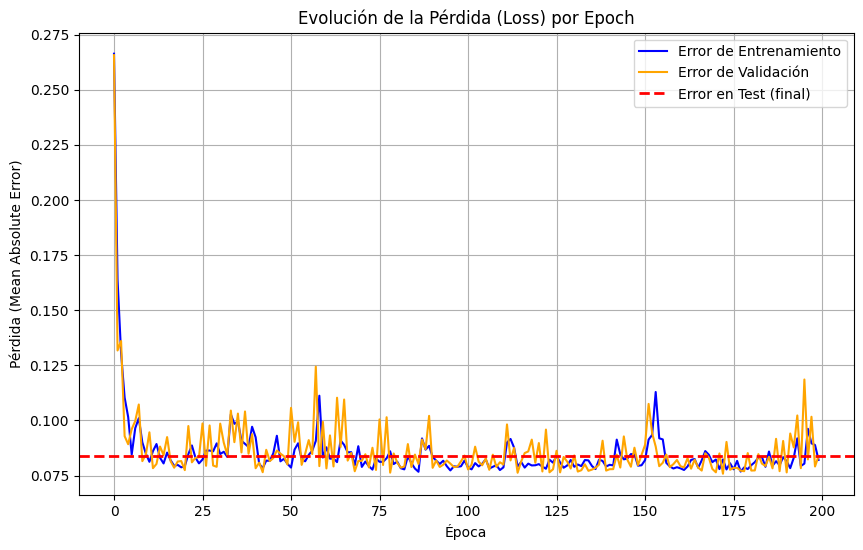

In [172]:
X = df[['Years of Experience', 'Education Level']]
y = df['Salary']

print("\nSplitting data: 60% train, 20% validation, 20% test...")
# Primera división: separar test (20%)
X_temp, X_test_M_a, y_temp, y_test_M_a = train_test_split(X, y, test_size=0.20, random_state=42)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M_a, X_val_M_a, y_train_M_a, y_val_M_a = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M_a = MinMaxScaler()
scaler_y_M_a = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_a_scaled = scaler_X_M_a.fit_transform(X_train_M_a)
y_train_M_a_scaled = scaler_y_M_a.fit_transform(y_train_M_a.values.reshape(-1, 1)).flatten()

# Solo transformar validation y test (sin fit)
X_val_M_a_scaled = scaler_X_M_a.transform(X_val_M_a)
y_val_M_a_scaled = scaler_y_M_a.transform(y_val_M_a.values.reshape(-1, 1)).flatten()

X_test_M_a_scaled = scaler_X_M_a.transform(X_test_M_a)
y_test_M_a_scaled = scaler_y_M_a.transform(y_test_M_a.values.reshape(-1, 1)).flatten()

# Modelo Multivariable
model_M_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_a_scaled.shape[1]], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 5 (Múltiples características)...')
history_M_a = model_M_a.fit(X_train_M_a_scaled, y_train_M_a_scaled, epochs=200, validation_data=(X_val_M_a_scaled, y_val_M_a_scaled))

# Evaluación final con el conjunto de TEST
loss_M_a = model_M_a.evaluate(X_test_M_a_scaled, y_test_M_a_scaled, verbose=0)
print(f'Pérdida Modelo 5 en Test: {loss_M_a}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_a.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M_a, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Absolute Error)')
plt.legend()
plt.grid(True)
plt.show()



Splitting data: 60% train, 20% validation, 20% test...
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 6 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3204 - val_loss: 0.2529
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1966 - val_loss: 0.1824
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1476 - val_loss: 0.1837
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1244 - val_loss: 0.1402
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1223 - val_loss: 0.1058
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0909 - val_loss: 0.1035
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0968 - val_loss: 0.0900
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0802 - val_loss: 0.0968
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0829 - val_loss: 0.0919
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0664 - val_loss: 0.0899
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0668 - val_loss: 0.0908
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0507 - val_loss: 0.0953
E

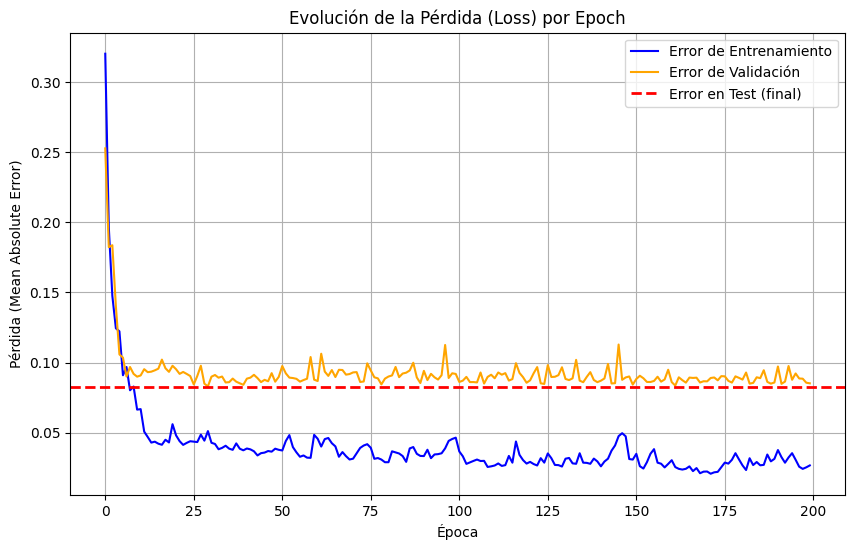

In [173]:
X = df.drop(columns=['Salary', 'Gender', 'Age'])
y = df['Salary']

print("\nSplitting data: 60% train, 20% validation, 20% test...")
# Primera división: separar test (20%)
X_temp, X_test_M_a_all, y_temp, y_test_M_a_all = train_test_split(X, y, test_size=0.20, random_state=42)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M_a_all, X_val_M_a_all, y_train_M_a_all, y_val_M_a_all = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M_a_all = MinMaxScaler()
scaler_y_M_a_all = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_a_all_scaled = scaler_X_M_a_all.fit_transform(X_train_M_a_all)
y_train_M_a_all_scaled = scaler_y_M_a_all.fit_transform(y_train_M_a_all.values.reshape(-1, 1)).flatten()

# Solo transformar validation y test (sin fit)
X_val_M_a_all_scaled = scaler_X_M_a_all.transform(X_val_M_a_all)
y_val_M_a_all_scaled = scaler_y_M_a_all.transform(y_val_M_a_all.values.reshape(-1, 1)).flatten()

X_test_M_a_all_scaled = scaler_X_M_a_all.transform(X_test_M_a_all)
y_test_M_a_all_scaled = scaler_y_M_a_all.transform(y_test_M_a_all.values.reshape(-1, 1)).flatten()

# Modelo Multivariable
model_M_a_all = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_a_all_scaled.shape[1]], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M_a_all.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 6 (Múltiples características)...')
history_M_a_all = model_M_a_all.fit(X_train_M_a_all_scaled, y_train_M_a_all_scaled, epochs=200, validation_data=(X_val_M_a_all_scaled, y_val_M_a_all_scaled))

# Evaluación final con el conjunto de TEST
loss_M_a_all = model_M_a_all.evaluate(X_test_M_a_all_scaled, y_test_M_a_all_scaled, verbose=0)
print(f'Pérdida Modelo 6 en Test: {loss_M_a_all}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M_a_all.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_a_all.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M_a_all, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Absolute Error)')
plt.legend()
plt.grid(True)
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


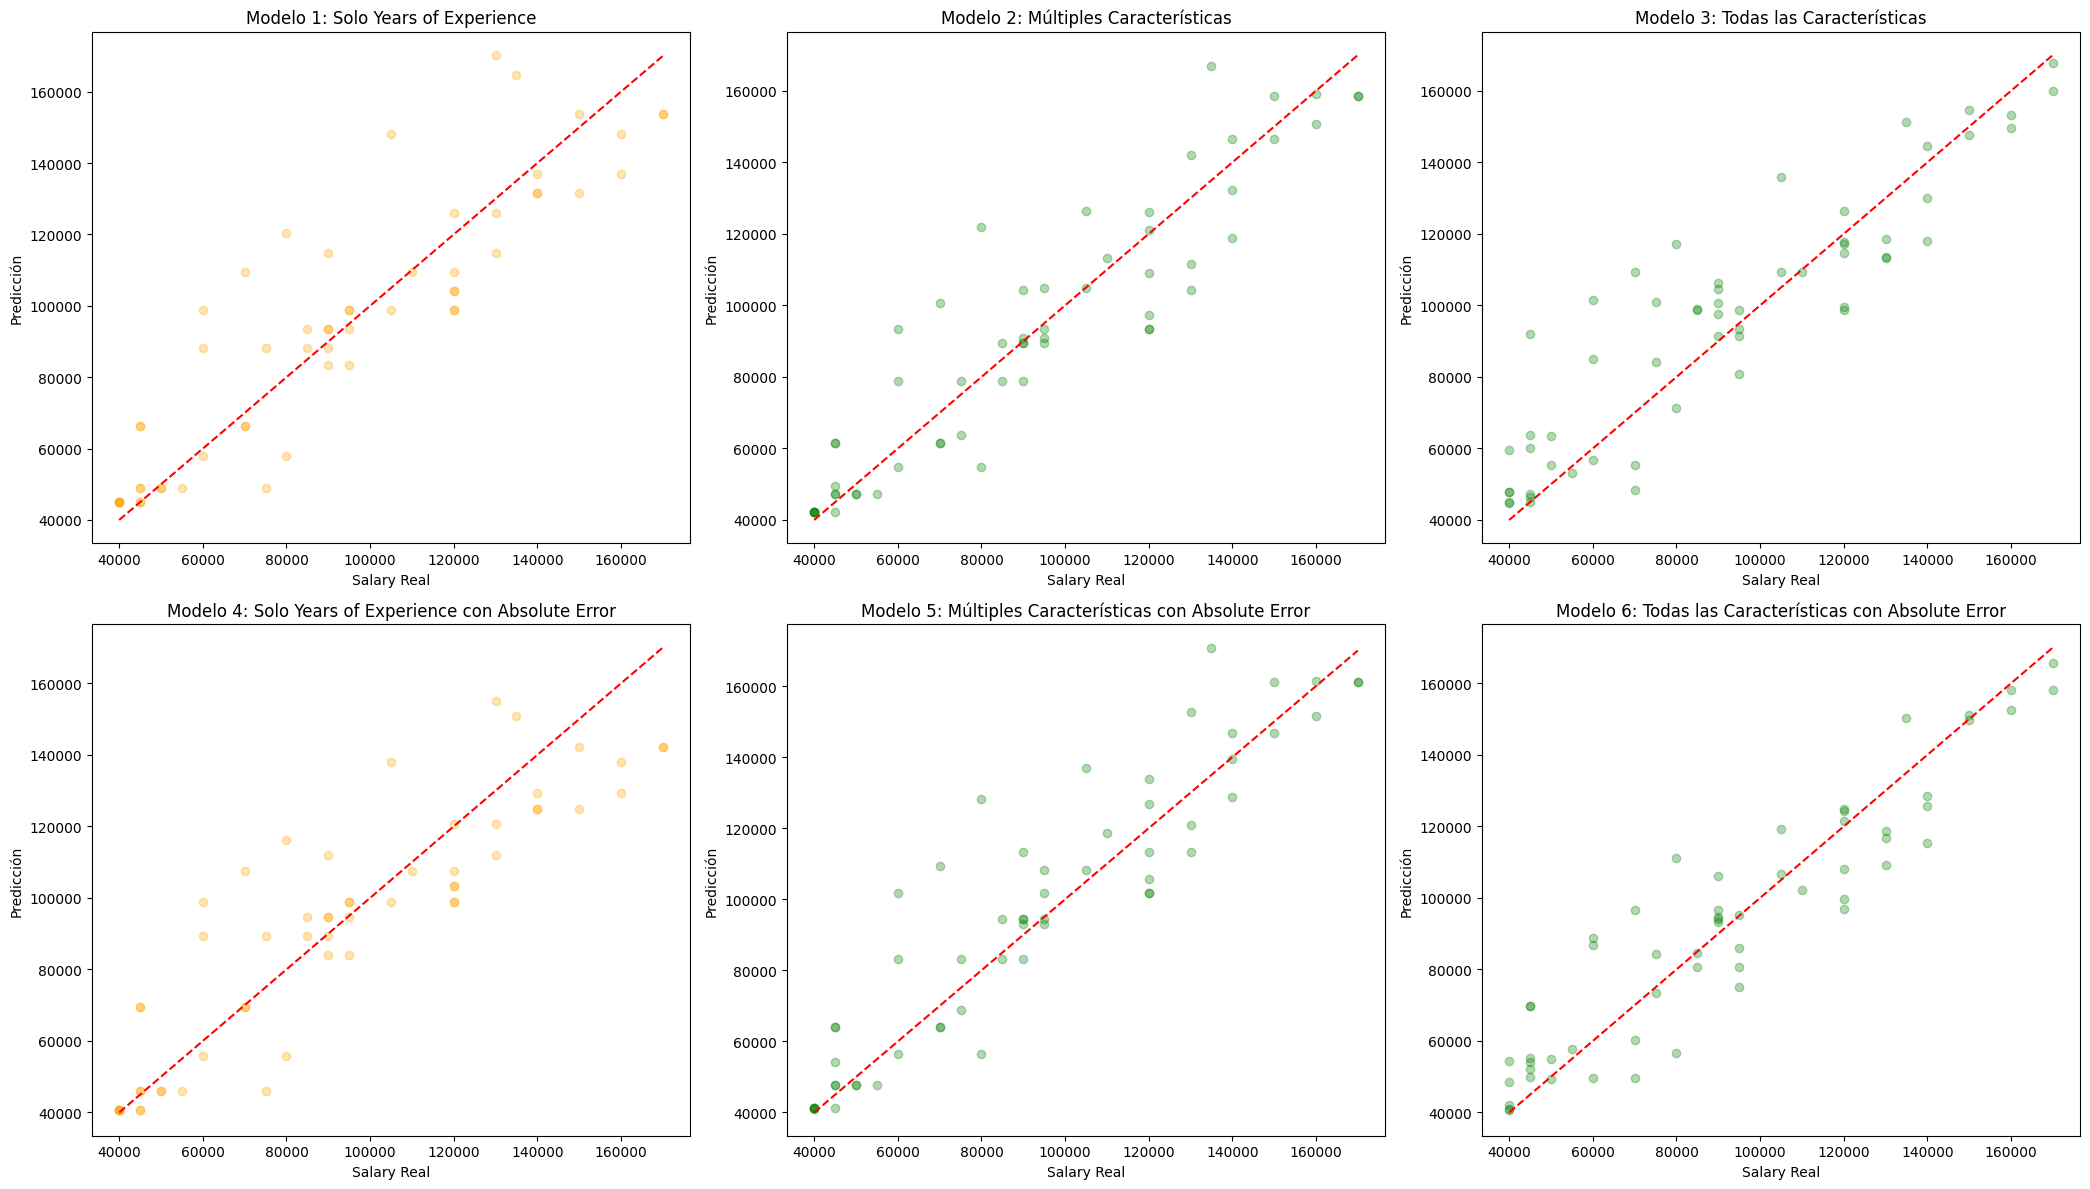


Comparativa de predicciones en conjunto de TEST:
       Real    Pred_Simple     Pred_Multi  Pred_Multi_All  \
0   40000.0   44938.757812   42118.429688    47812.253906   
1  130000.0  125937.570312  111475.546875   118634.968750   
2   70000.0   66366.140625   61565.003906    55430.957031   
3  150000.0  131477.046875  146464.984375   147698.609375   
4  120000.0  104100.906250  109125.562500   117870.257812   
5   75000.0   49053.761719   63713.648438    84096.109375   
6   85000.0   88207.460938   78995.710938    99054.656250   
7   70000.0   66366.140625   61565.003906    48476.968750   
8  140000.0  137016.546875  118884.062500   129978.742188   
9   85000.0   93499.179688   89503.882812    98717.218750   

   Pred_Simple_Absoluto  Pred_Multi_Absoluto  Pred_Multi_All_Absoluto  
0          40667.160156         41066.359375             42000.234375  
1         120548.554688        121032.539062            109191.554688  
2          69509.843750         64093.175781             60258

In [174]:
# Predicciones en el conjunto de TEST (desescaladas) usando el scaler correspondiente de cada modelo
pred_1 = scaler_y_1.inverse_transform(model_1.predict(X_test_1_scaled).reshape(-1, 1))
pred_M = scaler_y_M.inverse_transform(model_M.predict(X_test_M_scaled).reshape(-1, 1))
pred_M_all = scaler_y_M_all.inverse_transform(model_M_all.predict(X_test_M_all_scaled).reshape(-1, 1))
pred_1_a = scaler_y_1_a.inverse_transform(model_1_a.predict(X_test_1_a_scaled).reshape(-1, 1))
pred_M_a = scaler_y_M_a.inverse_transform(model_M_a.predict(X_test_M_a_scaled).reshape(-1, 1))
pred_M_a_all = scaler_y_M_a_all.inverse_transform(model_M_a_all.predict(X_test_M_a_all_scaled).reshape(-1, 1))

# Desescalar los valores reales de y_test de cada modelo
y_test_1_real = scaler_y_1.inverse_transform(y_test_1_scaled.reshape(-1, 1))
y_test_M_real = scaler_y_M.inverse_transform(y_test_M_scaled.reshape(-1, 1))
y_test_M_all_real = scaler_y_M_all.inverse_transform(y_test_M_all_scaled.reshape(-1, 1))
y_test_1_a_real = scaler_y_1_a.inverse_transform(y_test_1_a_scaled.reshape(-1, 1))
y_test_M_a_real = scaler_y_M_a.inverse_transform(y_test_M_a_scaled.reshape(-1, 1))
y_test_M_a_all_real = scaler_y_M_a_all.inverse_transform(y_test_M_a_all_scaled.reshape(-1, 1))

# Para la visualización, usamos el y_test del primer modelo
y_test = y_test_1_real

# Visualización
plt.figure(figsize=(21, 12))

plt.subplot(2, 3, 1)
plt.scatter(y_test, pred_1, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Modelo 1: Solo Years of Experience')
plt.xlabel('Salary Real')
plt.ylabel('Predicción')

plt.subplot(2, 3, 2)
plt.scatter(y_test, pred_M, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Modelo 2: Múltiples Características')
plt.xlabel('Salary Real')
plt.ylabel('Predicción')

plt.subplot(2, 3, 3)
plt.scatter(y_test, pred_M_all, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Modelo 3: Todas las Características')
plt.xlabel('Salary Real')
plt.ylabel('Predicción')

plt.subplot(2, 3, 4)
plt.scatter(y_test, pred_1_a, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Modelo 4: Solo Years of Experience con Absolute Error')
plt.xlabel('Salary Real')
plt.ylabel('Predicción')

plt.subplot(2, 3, 5)
plt.scatter(y_test, pred_M_a, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Modelo 5: Múltiples Características con Absolute Error')
plt.xlabel('Salary Real')
plt.ylabel('Predicción')

plt.subplot(2, 3, 6)
plt.scatter(y_test, pred_M_a_all, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Modelo 6: Todas las Características con Absolute Error')
plt.xlabel('Salary Real')
plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

# Tabla comparativa de los primeros 10 registros del conjunto de TEST
comparativa = pd.DataFrame({
    'Real': y_test.flatten()[:10],
    'Pred_Simple': pred_1.flatten()[:10],
    'Pred_Multi': pred_M.flatten()[:10],
    'Pred_Multi_All': pred_M_all.flatten()[:10],
    'Pred_Simple_Absoluto': pred_1_a.flatten()[:10],
    'Pred_Multi_Absoluto': pred_M_a.flatten()[:10],
    'Pred_Multi_All_Absoluto': pred_M_a_all.flatten()[:10]
})

diferencias = pd.DataFrame({
    'Real': y_test.flatten()[:10],
    'Diferencia_Simple_Cuadratico_Real': (pred_1.flatten()[:10] - y_test.flatten()[:10]),
    'Diferencia_Multi_Cuadratico_Real': (pred_M.flatten()[:10] - y_test.flatten()[:10]),
    'Diferencia_Multi_All_Cuadratico_Real': (pred_M_all.flatten()[:10] - y_test.flatten()[:10]),
    'Diferencia_Simple_Absoluto_Real': (pred_1_a.flatten()[:10] - y_test.flatten()[:10]),
    'Diferencia_Multi_Absoluto_Real': (pred_M_a.flatten()[:10] - y_test.flatten()[:10]),
    'Diferencia_Multi_All_Absoluto_Real': (pred_M_a_all.flatten()[:10] - y_test.flatten()[:10]),
    'Ganador_Cuadratico': np.where(
        abs(pred_1.flatten()[:10] - y_test.flatten()[:10]) <
        abs(pred_M.flatten()[:10] - y_test.flatten()[:10]),
        'Simple',
        'Multi'
    ),
    'Ganador_Absoluto': np.where(
        abs(pred_1_a.flatten()[:10] - y_test.flatten()[:10]) <
        abs(pred_M_a.flatten()[:10] - y_test.flatten()[:10]),
        'Simple',
        'Multi'
    )
})

cols_error = [
    'Diferencia_Simple_Cuadratico_Real', 
    'Diferencia_Multi_Cuadratico_Real', 
    'Diferencia_Multi_All_Cuadratico_Real',
    'Diferencia_Simple_Absoluto_Real', 
    'Diferencia_Multi_Absoluto_Real',
    'Diferencia_Multi_All_Absoluto_Real'
]

diferencias['Ganador_Global'] = diferencias[cols_error].abs().idxmin(axis=1).replace({
    'Diferencia_Simple_Cuadratico_Real': 'Simple Cuadrático',
    'Diferencia_Multi_Cuadratico_Real': 'Multi Cuadrático',
    'Diferencia_Multi_All_Cuadratico_Real': 'Multi All Cuadrático',
    'Diferencia_Simple_Absoluto_Real': 'Simple Absoluto',
    'Diferencia_Multi_Absoluto_Real': 'Multi Absoluto',
    'Diferencia_Multi_All_Absoluto_Real': 'Multi All Absoluto'
})

diferencias = diferencias.drop(columns=['Ganador_Cuadratico', 'Ganador_Absoluto'])

print('\nComparativa de predicciones en conjunto de TEST:')
print(comparativa)
print('\nDiferencias entre predicciones y valores reales en TEST:')
print(diferencias)



Resumen de Ganadores Globales y Métricas de Error:
                               MAE           MSE          RMSE        R²  \
Multi All Absoluto    10774.918380  1.906888e+08  13809.010272  0.870305   
Multi Cuadrático      10574.188117  2.114027e+08  14539.695201  0.856216   
Multi Absoluto        10907.922834  2.404203e+08  15505.491290  0.836480   
Multi All Cuadrático  12384.644052  2.701081e+08  16434.964971  0.816288   
Simple Cuadrático     12515.327303  2.949478e+08  17174.043593  0.799394   
Simple Absoluto       13094.431675  3.015837e+08  17366.164573  0.794881   

                      SMAPE (%)      SMSE  Número de Victorias  \
Multi All Absoluto    13.268969  0.030745                   17   
Multi Cuadrático      11.868541  0.025364                   10   
Multi Absoluto        11.958964  0.027941                    4   
Multi All Cuadrático  14.901082  0.040337                    9   
Simple Cuadrático     13.655098  0.033835                    6   
Simple Absoluto    

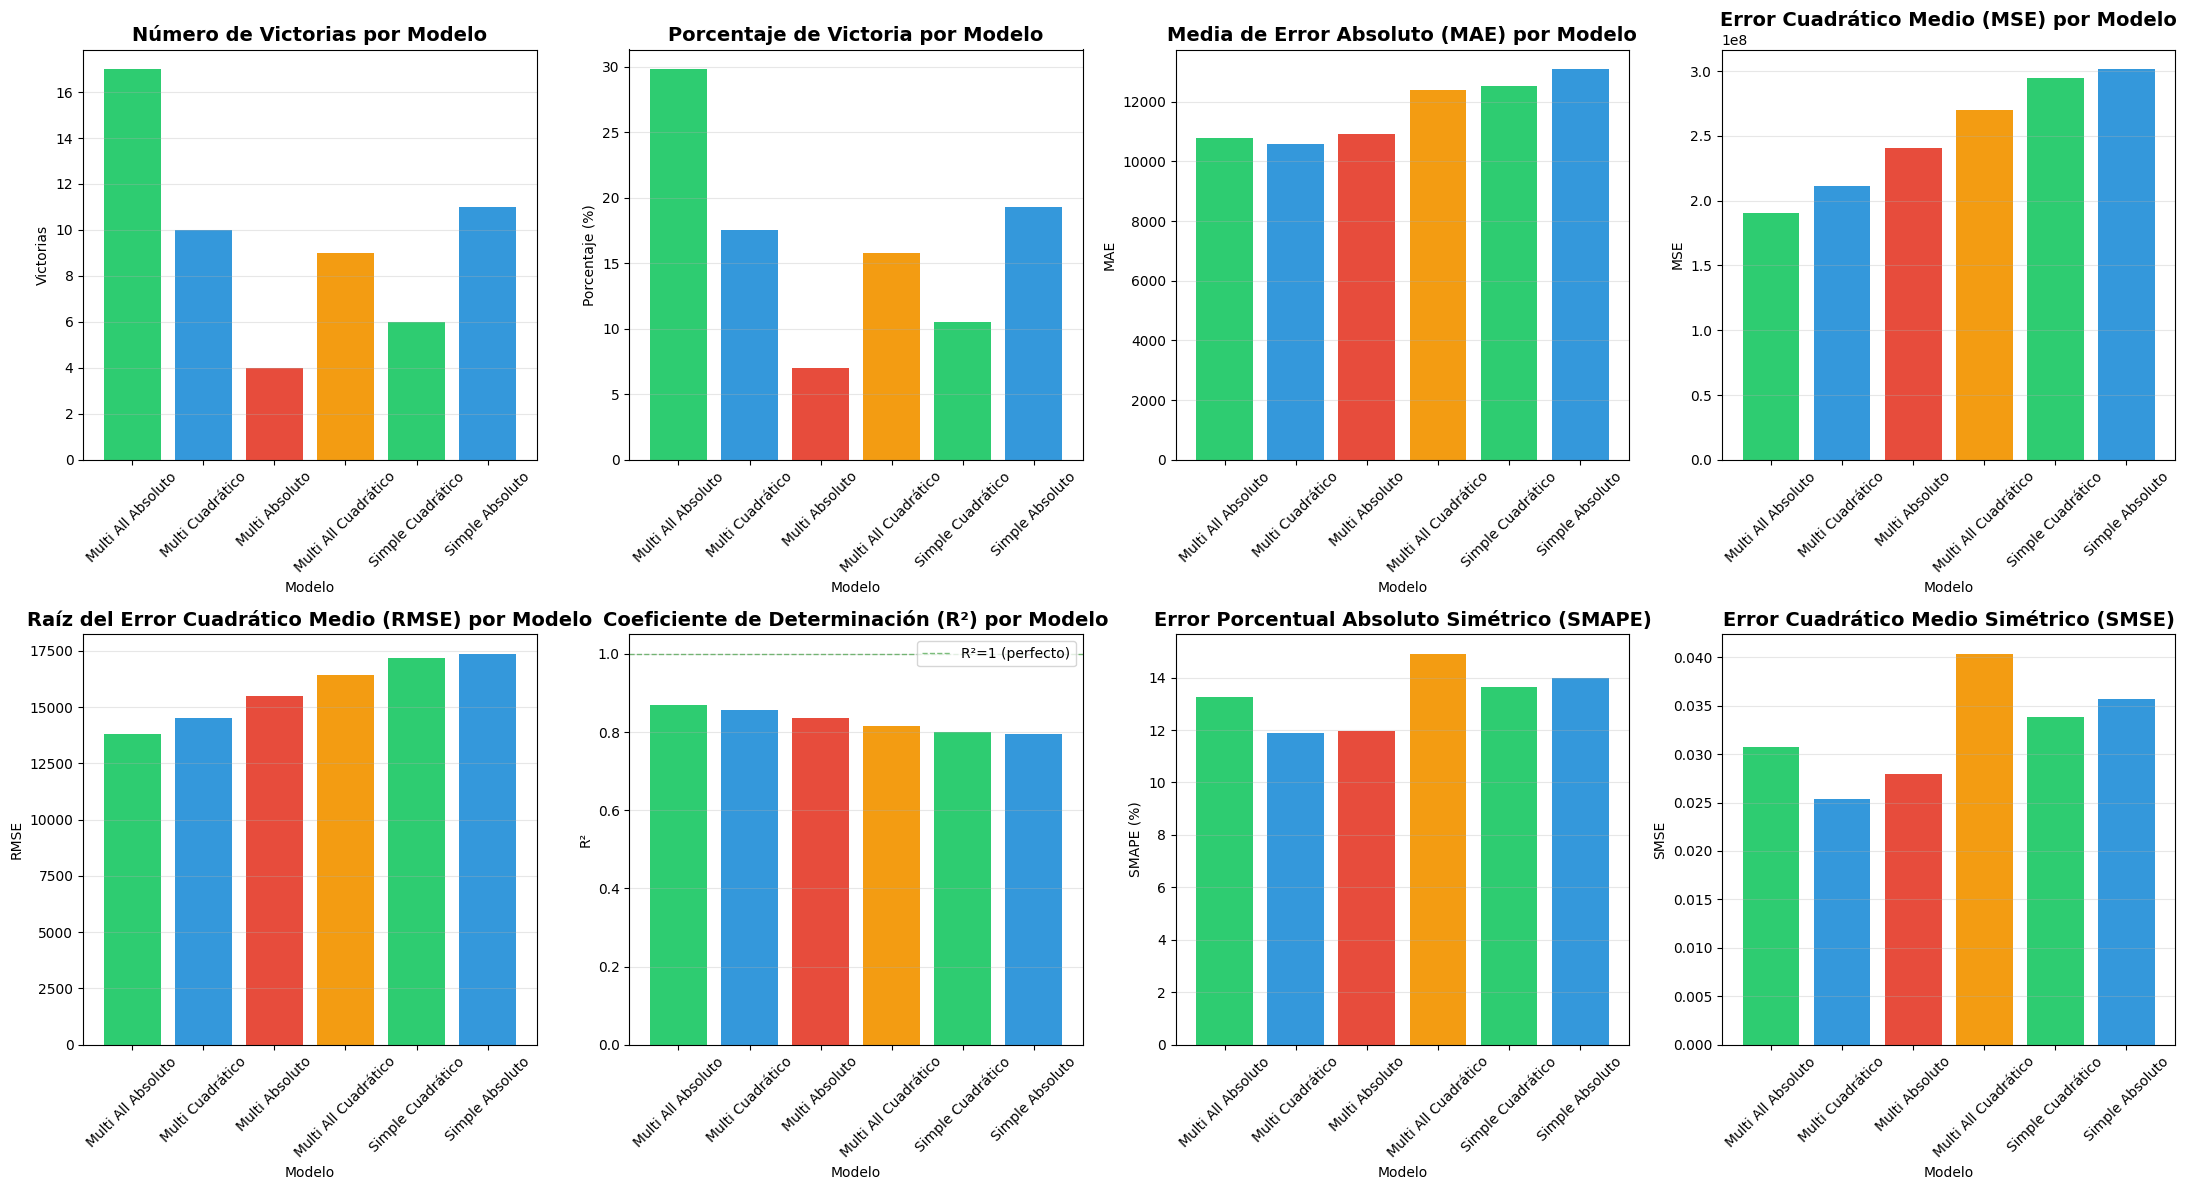

In [175]:
# Función para calcular SMAPE (Symmetric Mean Absolute Percentage Error)
def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

# Función para calcular SMSE (Symmetric Mean Squared Error)
def smse(y_true, y_pred):
    return np.mean(((y_pred - y_true) ** 2) / ((y_true ** 2 + y_pred ** 2) / 2))

# Cada modelo debe compararse con su propio conjunto de test real
modelos_data = {
    'Simple Cuadrático': (y_test_1_real.flatten(), pred_1.flatten()),
    'Multi Cuadrático': (y_test_M_real.flatten(), pred_M.flatten()),
    'Multi All Cuadrático': (y_test_M_all_real.flatten(), pred_M_all.flatten()),
    'Simple Absoluto': (y_test_1_a_real.flatten(), pred_1_a.flatten()),
    'Multi Absoluto': (y_test_M_a_real.flatten(), pred_M_a.flatten()),
    'Multi All Absoluto': (y_test_M_a_all_real.flatten(), pred_M_a_all.flatten())
}

metricas_dict = {}

for nombre, (real, pred) in modelos_data.items():
    mse_val = mean_squared_error(real, pred)
    metricas_dict[nombre] = {
        'MAE': mean_absolute_error(real, pred),
        'MSE': mse_val,
        'RMSE': np.sqrt(mse_val),
        'R²': r2_score(real, pred),
        'SMAPE (%)': smape(real, pred),
        'SMSE': smse(real, pred)
    }

# Calcular victorias comparando los errores absolutos de cada modelo
errores_totales = pd.DataFrame({
    'Simple Cuadrático': np.abs(pred_1.flatten() - y_test_1_real.flatten()),
    'Multi Cuadrático': np.abs(pred_M.flatten() - y_test_M_real.flatten()),
    'Multi All Cuadrático': np.abs(pred_M_all.flatten() - y_test_M_all_real.flatten()),
    'Simple Absoluto': np.abs(pred_1_a.flatten() - y_test_1_a_real.flatten()),
    'Multi Absoluto': np.abs(pred_M_a.flatten() - y_test_M_a_real.flatten()),
    'Multi All Absoluto': np.abs(pred_M_a_all.flatten() - y_test_M_a_all_real.flatten())
})

ganador_por_registro = errores_totales.idxmin(axis=1)
conteo_victorias = ganador_por_registro.value_counts()
porcentaje_victorias = ganador_por_registro.value_counts(normalize=True) * 100

resumen_rendimiento = pd.DataFrame(metricas_dict).T

resumen_rendimiento['Número de Victorias'] = conteo_victorias
resumen_rendimiento['Porcentaje de Victoria'] = porcentaje_victorias

resumen_rendimiento = resumen_rendimiento.sort_values(by='R²', ascending=False)

print('\nResumen de Ganadores Globales y Métricas de Error:')
print(resumen_rendimiento)

modelo_mejor_general = resumen_rendimiento.index[0]
print(f'\nEl modelo con mejor R² es: {modelo_mejor_general} - {resumen_rendimiento.loc[modelo_mejor_general, "R²"]:.4f}')
print(f'SMAPE del mejor modelo: {resumen_rendimiento.loc[modelo_mejor_general, "SMAPE (%)"]:.2f}%')

# Gráficos de barras del resumen
fig, axes = plt.subplots(2, 4, figsize=(22, 12))

# Gráfico 1: Número de Victorias
axes[0, 0].bar(resumen_rendimiento.index, resumen_rendimiento['Número de Victorias'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 0].set_title('Número de Victorias por Modelo', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Modelo')
axes[0, 0].set_ylabel('Victorias')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Porcentaje de Victoria
axes[0, 1].bar(resumen_rendimiento.index, resumen_rendimiento['Porcentaje de Victoria'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 1].set_title('Porcentaje de Victoria por Modelo', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Modelo')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: MAE
axes[0, 2].bar(resumen_rendimiento.index, resumen_rendimiento['MAE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 2].set_title('Media de Error Absoluto (MAE) por Modelo', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Modelo')
axes[0, 2].set_ylabel('MAE')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)

# Gráfico 4: MSE
axes[0, 3].bar(resumen_rendimiento.index, resumen_rendimiento['MSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0, 3].set_title('Error Cuadrático Medio (MSE) por Modelo', fontsize=14, fontweight='bold')
axes[0, 3].set_xlabel('Modelo')
axes[0, 3].set_ylabel('MSE')
axes[0, 3].tick_params(axis='x', rotation=45)
axes[0, 3].grid(axis='y', alpha=0.3)

# Gráfico 5: RMSE
axes[1, 0].bar(resumen_rendimiento.index, resumen_rendimiento['RMSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 0].set_title('Raíz del Error Cuadrático Medio (RMSE) por Modelo', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Modelo')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 6: R²
axes[1, 1].bar(resumen_rendimiento.index, resumen_rendimiento['R²'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 1].set_title('Coeficiente de Determinación (R²) por Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Modelo')
axes[1, 1].set_ylabel('R²')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(y=1.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='R²=1 (perfecto)')
axes[1, 1].legend()

# Gráfico 7: SMAPE
axes[1, 2].bar(resumen_rendimiento.index, resumen_rendimiento['SMAPE (%)'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 2].set_title('Error Porcentual Absoluto Simétrico (SMAPE)', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Modelo')
axes[1, 2].set_ylabel('SMAPE (%)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

# Gráfico 8: SMSE
axes[1, 3].bar(resumen_rendimiento.index, resumen_rendimiento['SMSE'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1, 3].set_title('Error Cuadrático Medio Simétrico (SMSE)', fontsize=14, fontweight='bold')
axes[1, 3].set_xlabel('Modelo')
axes[1, 3].set_ylabel('SMSE')
axes[1, 3].tick_params(axis='x', rotation=45)
axes[1, 3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
